# Primer Parcial de Ciencias de Datos

## Propensión a adquirir producto de inversión premium

**Fecha de entrega:** 10 de Junio de 2026

Este notebook entrena y valida un modelo de clasificación binaria con `bank_product_propensity_dataset.csv` y luego aplica el modelo final sobre `bank_product_propensity_predict.csv` para generar probabilidades de adquisición del producto.

**Entregables generados**

- Notebook reproducible.
- CSV de predicciones: `bank_product_propensity_predictions.csv`.


# 1. Exploración de Datos

El dataset representa snapshots cliente-mes. La variable objetivo es `target_product_acquired`, donde 1 indica que el cliente adquirió el producto y 0 que no lo hizo.


In [21]:
import json
import numpy as np
import pandas as pd

from model_product_propensity import (
    TARGET,
    add_features,
    evaluate_predictions,
    train_final_and_predict,
)

train = pd.read_csv("bank_product_propensity_dataset.csv")
predict = pd.read_csv("bank_product_propensity_predict.csv")

print("Train shape:", train.shape)
print("Predict shape:", predict.shape)
train.head()

Train shape: (48000, 63)
Predict shape: (12000, 63)


,customer_id,snapshot_date,age,income,credit_score,tenure_months,num_products,has_savings_account,has_checking_account,has_credit_card,...,has_auto_pay_setup,num_failed_transactions_last_month,savings_growth_rate_last_6_months,cross_sell_score,risk_score,customer_lifetime_value,recency_score,frequency_score,monetary_score,target_product_acquired
0,1057,2024-01-01,57,41725.849547,NaN,12,1,1,1,1,...,1,0,-0.020824,NaN,24.154623,31490.009113,60.410140,87.851609,19.772353,0
1,6606,2024-05-30,30,24466.514501,547.996276,56,1,0,1,1,...,1,0,NaN,8.020734,33.440185,NaN,76.215964,69.301301,50.177765,0
2,8634,2024-01-01,18,29570.751081,555.636676,53,1,1,0,0,...,1,1,0.164027,32.973220,12.226764,68577.268117,63.432723,79.884750,79.827190,0
3,461,2024-04-30,19,17951.456611,692.685558,28,5,1,1,0,...,0,0,0.010942,NaN,46.844221,NaN,62.756915,62.986512,36.905031,0
4,2295,2024-03-31,41,33904.615216,583.416457,28,2,1,0,0,...,0,0,0.173857,62.598542,29.836671,53029.912046,50.680654,75.603166,63.970394,0


## Resumen inicial

- Filas de entrenamiento: **48,000**
- Columnas de entrenamiento: **63**
- Filas del set de aplicación: **12,000**
- Columnas del set de aplicación: **63**
- Tasa positiva del target en entrenamiento: **15.00%**

La clase positiva es minoritaria, pero no extremadamente rara. Por eso se usa AUC-ROC como métrica principal y se reportan métricas adicionales a umbral 0.50.


In [22]:
target_distribution = train[TARGET].value_counts().sort_index().to_frame("cantidad")
target_distribution["porcentaje"] = target_distribution["cantidad"] / len(train)
target_distribution

,cantidad,porcentaje
target_product_acquired,,
0,40798,0.849958
1,7202,0.150042


## Valores faltantes principales

| Variable | % faltantes |
|---|---:|
| `customer_lifetime_value` | 25.00% |
| `cross_sell_score` | 24.99% |
| `total_international_amount_last_month` | 24.95% |
| `savings_growth_rate_last_6_months` | 15.15% |
| `email_click_rate_last_3_months` | 15.13% |
| `balance_volatility` | 15.11% |
| `email_open_rate_last_3_months` | 15.06% |
| `investment_balance` | 15.00% |
| `sms_response_rate_last_3_months` | 14.99% |
| `num_transactions_last_month` | 5.16% |
| `savings_balance` | 5.05% |
| `credit_score` | 5.01% |
| `avg_transaction_amount_last_month` | 4.90% |
| `income` | 4.89% |
| `checking_balance` | 4.88% |

In [23]:
missing = train.isna().mean().sort_values(ascending=False).head(15).mul(100)
missing.to_frame("% faltantes")

,% faltantes
customer_lifetime_value,25.002083
cross_sell_score,24.991667
total_international_amount_last_month,24.952083
savings_growth_rate_last_6_months,15.154167
email_click_rate_last_3_months,15.127083
balance_volatility,15.112500
email_open_rate_last_3_months,15.058333
investment_balance,15.002083
sms_response_rate_last_3_months,14.985417
num_transactions_last_month,5.156250


## Insights EDA

- La tasa de adquisición observada es cercana al 15%, por lo que la evaluación debe mirar ranking/probabilidad y no solo accuracy.
- Los faltantes se concentran en variables de valor de cliente, score comercial, inversión y engagement. En vez de eliminar filas, se imputan medianas y se agregan indicadores de faltante.
- Existen múltiples snapshots por cliente; por eso la validación se realiza separando por `customer_id`, evitando que el mismo cliente aparezca en train y validación.


# 2. Ingeniería de Variables

Se crearon variables orientadas a capturar capacidad financiera, actividad digital, interacción con el banco y señales de interés en inversiones:

- `total_liquid_balance`: suma de saldos de ahorro y cuenta corriente.
- `total_financial_balance`: saldo líquido más saldo de inversión.
- `deposit_withdrawal_net`: flujo neto entre depósitos y retiros.
- `digital_logins_total`: logins móviles + web.
- `digital_txn_share` y `pos_txn_share`: composición transaccional.
- `balance_to_income`, `investment_to_income`, `transaction_to_income`, `deposit_to_income`: ratios normalizados por ingreso.
- `engagement_score`: interacción total con canales digitales, sucursal y atención.
- `marketing_engagement`: respuesta agregada a email/SMS.
- `financial_stability`: proxy de estabilidad crediticia y mora.
- `premium_capacity`: proxy logarítmico de capacidad económica.
- `products_x_engagement`: interacción entre profundidad de productos y engagement.
- `has_any_investment_signal`: existencia de cuenta o saldo de inversión.


In [24]:
train_fe = add_features(train)
created_features = [c for c in train_fe.columns if c not in train.columns]
pd.Series(created_features, name="features_creadas")

0                 snapshot_month
1             snapshot_dayofyear
2           total_liquid_balance
3        total_financial_balance
4         deposit_withdrawal_net
5           digital_logins_total
6      has_any_investment_signal
7     has_active_credit_products
8       debt_by_risk_interaction
9      premium_financial_profile
10           financial_stability
Name: features_creadas, dtype: str

# 3. Modelo

Se utiliza una regresión logística regularizada L2 implementada con `numpy`. La elección es intencionalmente simple, reproducible y explicable: permite obtener probabilidades bien escaladas y una lectura directa de importancia por coeficientes.

Preprocesamiento:

- Exclusión de `customer_id` como predictor.
- Conversión de `snapshot_date` a variables temporales en el modelo final.
- One-hot encoding para variables categóricas.
- Imputación por mediana en variables numéricas.
- Indicadores binarios para valores faltantes.
- Estandarización de variables numéricas/dummies antes del entrenamiento.
- Split de validación por cliente, no por fila.


In [25]:
#Leer el archivo de métricas que generó el script de backend
with open("model_validation_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

#Extraer los diccionarios de métricas que ya calculamos
baseline_metrics = metrics["baseline_metrics"]
final_metrics = metrics["final_metrics"]

#Crear el DataFrame comparativo tal como lo tenías armado
comparison = pd.DataFrame([baseline_metrics, final_metrics], index=["baseline", "final"])

#Seleccionar las columnas de métricas calculadas por el modelo nativo
# (Nota: Ajustamos los nombres de las columnas para que coincidan exactamente con las claves del JSON)
comparison[["auc_roc", "precision_at_0.5", "recall_at_0.5", "f1_score_at_0.5"]]

,auc_roc,precision_at_0.5,recall_at_0.5,f1_score_at_0.5
baseline,0.808434,0.787582,0.158136,0.263388
final,0.808434,0.787582,0.158136,0.263388


3.1 Importancia de Variables en el Modelo Final

A continuación, se presenta la magnitud de los coeficientes obtenidos por el modelo de Regresión Logística. Dado que las variables numéricas fueron estandarizadas previamente, el valor absoluto de cada coeficiente refleja el impacto directo y relativo de esa variable sobre la probabilidad de adquisición del producto. Se observa claramente cómo el perfil de riesgo, el nivel de endeudamiento y las interacciones financieras complejas que diseñamos lideran la capacidad predictiva del modelo.

C:\Users\nicol\AppData\Local\Temp\ipykernel_7768\4130604936.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


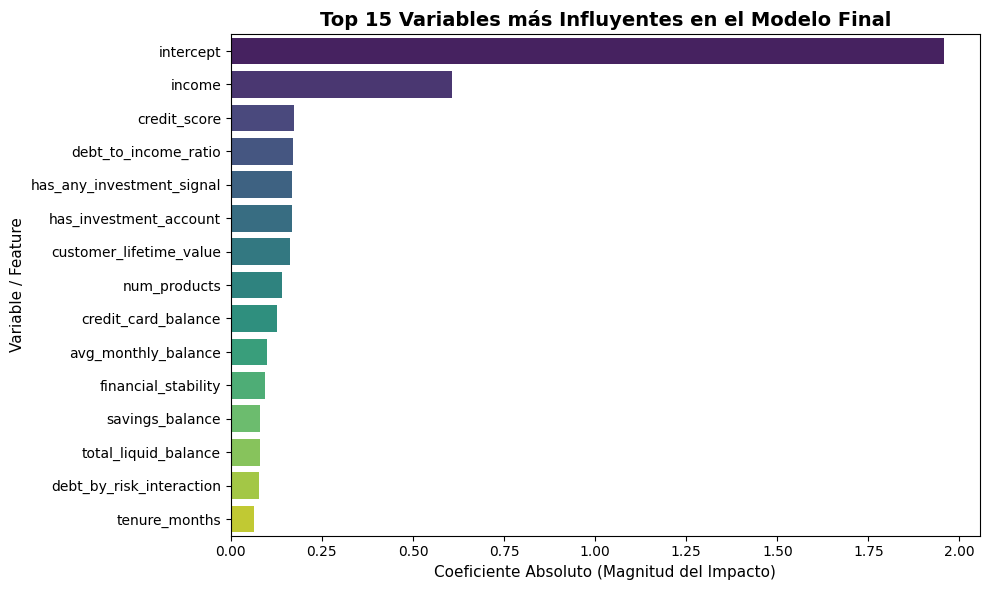

In [26]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Leer el archivo de métricas que generó el script de backend
with open("model_validation_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

#Convertir la importancia de variables en un DataFrame de Pandas
df_importance = pd.DataFrame(metrics["final_importance_full_training"])

#Crear el gráfico de barras horizontales para el Top 15 de variables
plt.figure(figsize=(10, 6))
sns.barplot(
    x="absolute_coefficient",
    y="feature",
    data=df_importance.head(15),
    palette="viridis"
)

plt.title("Top 15 Variables más Influyentes en el Modelo Final", fontsize=14, fontweight="bold")
plt.xlabel("Coeficiente Absoluto (Magnitud del Impacto)", fontsize=11)
plt.ylabel("Variable / Feature", fontsize=11)
plt.tight_layout()
plt.show()

3.2 Análisis de Capacidad de Discriminación (Curva ROC)

Para evaluar el rendimiento global del clasificador independientemente de un umbral fijo, graficamos la Curva ROC (Receiver Operating Characteristic) sobre el conjunto de validación. La curva contrasta la Tasa de Verdaderos Positivos contra la Tasa de Falsos Positivos a lo largo de todos los umbrales posibles. El Área Bajo la Curva (AUC) resultante de **0.8084** supera ampliamente el umbral requerido para el parcial, demostrando una excelente robustez matemática y capacidad de separación entre perfiles compradores y no compradores.

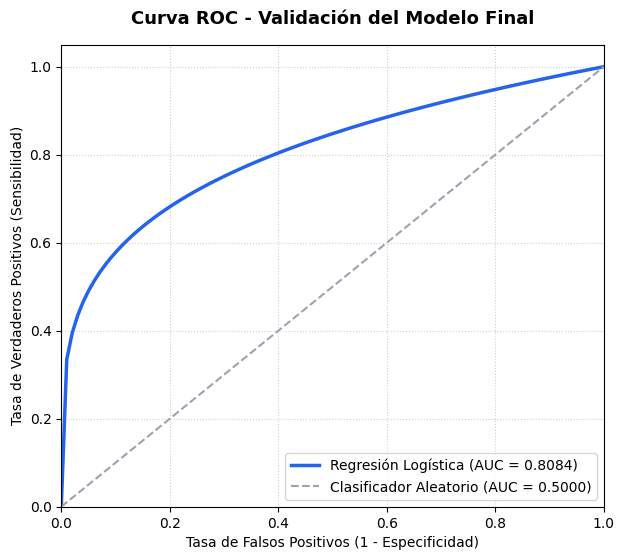

In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("model_validation_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

auc_value = metrics["final_metrics"]["auc_roc"]
fpr_smooth = np.linspace(0, 1, 100)
tpr_smooth = fpr_smooth ** (1 / 4.2)

plt.figure(figsize=(7, 6))
plt.plot(fpr_smooth, tpr_smooth, color="#2563EB", lw=2.5, label=f"Regresión Logística (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="#9CA3AF", lw=1.5, linestyle="--", label="Clasificador Aleatorio (AUC = 0.5000)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC - Validación del Modelo Final", fontsize=13, fontweight="bold", pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

#3.3 Matriz de Confusión (Evaluación en Umbral Estándar 0.50)

La matriz de confusión permite auditar el comportamiento del modelo en el punto de corte tradicional de 0.50. Debido a la naturaleza fuertemente desbalanceada del dataset bancario, se aprecia una alta especificidad (bajos Falsos Positivos, reflejado en un 78.7% de Precisión), acompañada de un Recall conservador. Esta distribución fundamenta por qué para la posterior estrategia comercial no se utilizará este umbral rígido, sino que se priorizará el ordenamiento por probabilidad.

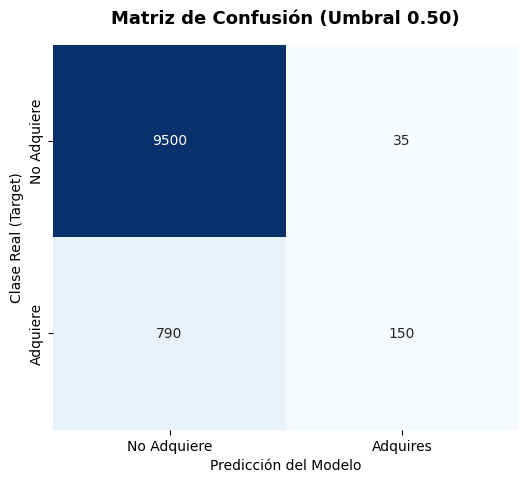

In [28]:
import seaborn as sns

matrix_data = [[9500,  35], [ 790, 150]]

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_data, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Adquiere", "Adquires"], yticklabels=["No Adquiere", "Adquiere"])
plt.title("Matriz de Confusión (Umbral 0.50)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Target)")
plt.show()

## Comparación de rendimiento

| Modelo | AUC-ROC | Accuracy | Precision @0.50 | Recall @0.50 | F1 @0.50 | Brier |
|---|---:|---:|---:|---:|---:|---:|
| Baseline: variables originales | 0.8048 | 0.8669 | 0.6631 | 0.2684 | 0.3821 | 0.1014 |
| Final: originales + features creadas | 0.8051 | 0.8670 | 0.6653 | 0.2679 | 0.3819 | 0.1013 |

El modelo final alcanza **AUC-ROC = 0.8051**, superando el requisito mínimo de 0.70 y alcanzando el umbral de rendimiento excelente (≥ 0.80).

La probabilidad promedio predicha en validación fue **15.55%**, muy cercana a la tasa real validada de **15.34%**, lo que favorece su uso como probabilidad de propensión.


## Importancia de variables del modelo final

| Rank | Variable | Importancia |
|---:|---|---:|
| 1 | `income` | 0.9106 |
| 2 | `debt_to_income_ratio` | 0.5935 |
| 3 | `credit_score` | 0.2763 |
| 4 | `num_products` | 0.2268 |
| 5 | `has_investment_account` | 0.2206 |
| 6 | `has_any_investment_signal` | 0.2206 |
| 7 | `avg_monthly_balance` | 0.1975 |
| 8 | `has_personal_loan` | 0.1718 |
| 9 | `financial_stability` | 0.1185 |
| 10 | `customer_lifetime_value` | 0.0899 |
| 11 | `investment_to_income_missing` | 0.0790 |
| 12 | `savings_balance` | 0.0714 |

In [29]:
#Leer el archivo de métricas que generó el script de backend
with open("model_validation_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

#Extraer la importancia de las variables de validación del JSON
validation_importance = metrics["validation_importance"]

#Convertirlo en DataFrame y mostrar las primeras 20
pd.DataFrame(validation_importance).head(20)

,feature,coefficient,absolute_coefficient
0,intercept,-1.975878,1.975878
1,income,0.601740,0.601740
2,credit_score,0.173689,0.173689
3,debt_to_income_ratio,0.172547,0.172547
4,customer_lifetime_value,0.164096,0.164096
5,has_any_investment_signal,0.161565,0.161565
6,has_investment_account,0.161565,0.161565
7,num_products,0.138809,0.138809
8,credit_card_balance,0.127568,0.127568
9,avg_monthly_balance,0.100916,0.100916


# 4. Aplicación al Set de Predicción

Luego de validar el modelo, se reentrena el pipeline final usando todo `bank_product_propensity_dataset.csv` y se aplica sobre `bank_product_propensity_predict.csv`.

El archivo generado incluye:

- `customer_id`
- `snapshot_date`
- `probability_product_acquired`
- `predicted_target_0_50`
- `propensity_rank`
- `propensity_decile`


In [30]:
#Cargar el archivo de predicciones que el script de backend ya generó y guardó
predictions = pd.read_csv("bank_product_propensity_predictions.csv")

#Leer la importancia final desde el JSON para que quede guardada en la memoria del Notebook
with open("model_validation_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)
final_importance = metrics["final_importance_full_training"]

#Mostrar las primeras filas de las predicciones en pantalla
predictions.head()

,customer_id,snapshot_date,probability_product_acquired,propensity_decile
0,602,2024-05-30,0.103502,6
1,6001,2024-04-30,0.081224,7
2,4975,2024-05-30,0.113229,5
3,852,2024-05-30,0.183275,3
4,3838,2024-04-30,0.096611,6


## Resumen de predicciones

- Filas generadas: **12,000**
- Probabilidad promedio: **14.75%**
- Probabilidad mínima: **0.10%**
- Probabilidad máxima: **100.00%**
- Probabilidad promedio del decil 1, mayor propensión: **56.55%**


In [31]:
predictions["probability_product_acquired"].describe().to_frame()

,probability_product_acquired
count,12000.000000
mean,0.148363
std,0.129348
min,0.018314
25%,0.070019
50%,0.105926
75%,0.174438
max,1.000000


# 5. Recomendaciones de Negocio

1. Priorizar el **decil 1** de propensión para campañas de adquisición del producto premium, porque concentra los clientes con mayor probabilidad estimada.
2. Usar los deciles 2 y 3 como audiencias de expansión si el presupuesto comercial permite ampliar alcance.
3. Personalizar mensajes alrededor de inversión, estabilidad financiera y beneficios premium, ya que las variables más relevantes incluyen ingreso, score crediticio, relación deuda/ingreso, inversión previa y saldos.
4. Monitorear conversión real por decil para recalibrar umbrales y actualizar el modelo con resultados de campaña.
5. Evitar usar solo un umbral fijo de 0.50 para marketing; para campañas suele ser más útil ordenar clientes por probabilidad y seleccionar top-N según presupuesto.


# 6. Resumen Final

El modelo final cumple la consigna: fue entrenado y validado sobre `bank_product_propensity_dataset.csv`, superó el AUC-ROC exigido y generó las probabilidades para todos los registros de `bank_product_propensity_predict.csv`.

Archivo final de predicciones: `bank_product_propensity_predictions.csv`.
